In [27]:
!pip install earthengine-api geemap pandas matplotlib seaborn osmnx geopandas scikit-learn shapely openpyxl

In [ ]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Trigger the authentication flow. This will open a new tab to log in to your Google account.
# You only need to do this once.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='ee-uhi-project') # Replace with your GCP project ID if required, or just ee.Initialize()

In [ ]:
import ee
import os
import pandas as pd
import numpy as np
import osmnx as ox
import geopandas as gpd

# File paths for our checkpoints
gee_file = 'bengaluru_gee_features.csv'
osmnx_file = 'bengaluru_morphology_features.csv'

# Shrinking the ROI to Central Bengaluru to prevent OSMnx kernel crashes
# [West, South, East, North]
lon_min, lat_min, lon_max, lat_max = 77.55, 12.90, 77.65, 13.00
gee_roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])

# ==========================================
# STEP 1: GOOGLE EARTH ENGINE DATA
# ==========================================
if os.path.exists(gee_file):
    print(f"Loading GEE data from {gee_file}...")
    df_gee = pd.read_csv(gee_file)
else:
    print("Pulling GEE data from Google's servers. This takes ~30 seconds...")
    ee.Initialize(project='ee-uhi-project') # Assuming your project is registered
    
    # 1. Multispectral & Target Variable
    def prep_landsat(image):
        qa = image.select('QA_PIXEL')
        mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
        lst = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
        ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
        ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
        mndwi = image.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')
        # EVI and SAVI
        evi = image.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('SR_B5'), 'RED': image.select('SR_B4'), 'BLUE': image.select('SR_B2')
        }).rename('EVI')
        savi = image.expression('((NIR - RED) / (NIR + RED + 0.5)) * (1.5)', {
            'NIR': image.select('SR_B5'), 'RED': image.select('SR_B4')
        }).rename('SAVI')
        return image.updateMask(mask).addBands([lst, ndvi, ndbi, mndwi, evi, savi])

    l8_data = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(gee_roi).filterDate('2023-03-01', '2023-05-31').map(prep_landsat).median()

    # 2. Climate & Human Activity
    era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").filterBounds(gee_roi).filterDate('2023-03-01', '2023-05-31').median()
    wind_speed = era5.select('u_component_of_wind_10m').pow(2).add(era5.select('v_component_of_wind_10m').pow(2)).sqrt().rename('Wind_Speed')
    temp_air = era5.select('temperature_2m')
    temp_dew = era5.select('dewpoint_temperature_2m')
    rh = ee.Image(100).subtract(ee.Image(5).multiply(temp_air.subtract(temp_dew))).rename('Relative_Humidity')
    
    pop_density = ee.ImageCollection("WorldPop/GP/100m/pop").filterBounds(gee_roi).median().rename('Pop_Density')
    no2 = ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2").filterBounds(gee_roi).filterDate('2023-03-01', '2023-05-31').median().select('NO2_column_number_density').rename('NO2_Emissions')

    # 3. Stack and Sample
    master_image = ee.Image([l8_data.select(['LST', 'NDVI', 'NDBI', 'MNDWI', 'EVI', 'SAVI']), wind_speed, rh, pop_density, no2])
    sample_grid = master_image.sample(region=gee_roi, scale=100, numPixels=2500, geometries=True)

    # 4. Convert to DataFrame and Save
    features = sample_grid.getInfo()['features']
    df_gee = pd.DataFrame([f['properties'] for f in features])
    df_gee['Longitude'] = [f['geometry']['coordinates'][0] for f in features]
    df_gee['Latitude'] = [f['geometry']['coordinates'][1] for f in features]
    
    df_gee.to_csv(gee_file, index=False)
    print(f"Saved GEE data to {gee_file}!")

# ==========================================
# STEP 2: OPENSTREETMAP MORPHOLOGY DATA
# ==========================================
import numpy as np
import shapely.wkt

if os.path.exists(osmnx_file):
    print(f"Loading Morphology data from {osmnx_file}...")
    buildings_df = pd.read_csv(osmnx_file)
    # Convert the text back into spatial polygons
    buildings_df['geometry'] = buildings_df['geometry_wkt'].apply(shapely.wkt.loads)
    buildings_proj = gpd.GeoDataFrame(buildings_df, geometry='geometry', crs="EPSG:32643")
else:
    print("Pulling OSM Morphology data. Because we shrank the ROI, this should take ~2 to 4 minutes...")
    
    bbox = (lon_min, lat_min, lon_max, lat_max) 
    tags = {'building': True}
    
    # Pull the vector data
    buildings = ox.features_from_bbox(bbox=bbox, tags=tags)    
    
    # Extract raw height and levels
    buildings['height_raw'] = pd.to_numeric(buildings.get('height', pd.Series(dtype=float)), errors='coerce')
    
    if 'building:levels' in buildings.columns:
        buildings['levels'] = pd.to_numeric(buildings['building:levels'], errors='coerce')
    else:
        buildings['levels'] = np.nan
    
    # Project to calculate precise area in square meters
    buildings_proj = buildings.to_crs(epsg=32643)
    buildings_proj['bldg_area'] = buildings_proj.geometry.area
    
    # The Strict Extraction Function (No Heuristics)
    def extract_strict_height(row):
        if pd.notna(row['height_raw']):
            return row['height_raw']
        elif pd.notna(row['levels']):
            return row['levels'] * 3.0 
        else:
            return np.nan
    
    # Apply the strict function
    buildings_proj['height'] = buildings_proj.apply(extract_strict_height, axis=1)
    
    # Calculate volume ONLY for buildings where we know the height
    buildings_proj['bldg_volume'] = buildings_proj['bldg_area'] * buildings_proj['height']
    
    # Convert geometry to text so it can be safely saved in a CSV
    buildings_proj['geometry_wkt'] = buildings_proj.geometry.apply(lambda x: x.wkt)
    
    # Keep only the features we need to save disk space
    cols_to_keep = ['height', 'bldg_area', 'bldg_volume', 'geometry_wkt']
    buildings_df = pd.DataFrame(buildings_proj[cols_to_keep])
    
    buildings_df.to_csv(osmnx_file, index=False)
    print(f"Saved Morphology data to {osmnx_file}!")

print("\n--- Both datasets are ready in your environment! ---")

In [ ]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import numpy as np

print("Starting the Spatial Merge with Strict Height Extraction...")

# 1. Load the GEE points and convert to a spatial format
df_gee = pd.read_csv('bengaluru_gee_features.csv')
gdf_gee = gpd.GeoDataFrame(
    df_gee, 
    geometry=gpd.points_from_xy(df_gee.Longitude, df_gee.Latitude),
    crs="EPSG:4326"
)

# Project to meters (UTM Zone 43N for Bengaluru)
gdf_gee_proj = gdf_gee.to_crs(epsg=32643)

# Create a 50-meter radius buffer around each point (representing our ~100m grid cell)
gdf_gee_proj['geometry'] = gdf_gee_proj.geometry.buffer(50)

# 2. Re-pull the Buildings and Apply Strict Height Logic
bbox = (77.55, 12.90, 77.65, 13.00) 
buildings = ox.features_from_bbox(bbox=bbox, tags={'building': True})

buildings['height_raw'] = pd.to_numeric(buildings.get('height', pd.Series(dtype=float)), errors='coerce')
if 'building:levels' in buildings.columns:
    buildings['levels'] = pd.to_numeric(buildings['building:levels'], errors='coerce')
else:
    buildings['levels'] = np.nan

buildings_proj = buildings.to_crs(epsg=32643)
buildings_proj['bldg_area'] = buildings_proj.geometry.area

def extract_strict_height(row):
    if pd.notna(row['height_raw']):
        return row['height_raw']
    elif pd.notna(row['levels']):
        return row['levels'] * 3.0 
    else:
        return np.nan

buildings_proj['height'] = buildings_proj.apply(extract_strict_height, axis=1)

# 3. The Spatial Join (Fusing the data)
# Find which buildings intersect with which 50m grid buffer
joined = gpd.sjoin(buildings_proj[['bldg_area', 'height', 'geometry']], gdf_gee_proj, how='inner', predicate='intersects')

# Aggregate! Sum the area, but take the MEAN of the height. 
# (Pandas automatically ignores NaNs when calculating mean. If all are NaN, the mean is NaN!)
morphology_stats = joined.groupby('index_right').agg({
    'bldg_area': 'sum',
    'height': 'mean' 
})

# 4. Merge back to the main DataFrame
final_df = gdf_gee_proj.merge(morphology_stats, left_index=True, right_index=True, how='left')

# If 'bldg_area' is NaN after the merge, it means NO buildings exist in that cell. We fill area with 0.
final_df['bldg_area'] = final_df['bldg_area'].fillna(0)

# 5. Calculate our "Future Work" density metrics
cell_area = 3.14159 * (50**2) 
final_df['Building_Density_Ratio'] = final_df['bldg_area'] / cell_area

# Calculate Volume Density (Total Area * Mean Height) / Cell Area
# If height is NaN, Volume_Density becomes NaN, which is exactly what we want for the imputer!
final_df['Volume_Density'] = (final_df['bldg_area'] * final_df['height']) / cell_area

# Drop the heavy geometry column and intermediate columns
final_tabular_df = pd.DataFrame(final_df.drop(columns=['geometry', 'bldg_area', 'height']))

# Save the final dataset
final_tabular_df.to_csv('master_uhi_dataset.csv', index=False)

print("\n--- MASTER DATASET CREATED! ---")
print("Total Features:", final_tabular_df.shape[1])
print("Total Data Points:", final_tabular_df.shape[0])
print(f"Missing Volume Densities to Impute: {final_tabular_df['Volume_Density'].isna().sum()}")
display(final_tabular_df.head())

In [ ]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import numpy as np
import ee
import shapely.wkt

print("Starting the Ultimate Feature Expansion...")

# 1. Load Existing Data
df_master = pd.read_csv('master_uhi_dataset.csv')
gdf_points = gpd.GeoDataFrame(df_master, geometry=gpd.points_from_xy(df_master.Longitude, df_master.Latitude), crs="EPSG:4326")
gdf_points_proj = gdf_points.to_crs(epsg=32643)

# ==========================================
# PART A: SPATIAL PROXIMITY & MORPHOLOGY
# ==========================================
print("Pulling vector data for Streets, Parks, and Water...")
bbox = (77.55, 12.90, 77.65, 13.00) # (West, South, East, North)

# Pull geometries
water = ox.features_from_bbox(bbox=bbox, tags={'natural': 'water', 'waterway': True}).to_crs(epsg=32643)
parks = ox.features_from_bbox(bbox=bbox, tags={'leisure': 'park', 'landuse': 'recreation_ground'}).to_crs(epsg=32643)
highways = ox.features_from_bbox(bbox=bbox, tags={'highway': ['motorway', 'trunk', 'primary']}).to_crs(epsg=32643)
all_roads = ox.features_from_bbox(bbox=bbox, tags={'highway': True}).to_crs(epsg=32643)

# STRIP COMPLEX INDICES to prevent GeoPandas merge errors
water_geom = water[['geometry']].reset_index(drop=True)
parks_geom = parks[['geometry']].reset_index(drop=True)
highways_geom = highways[['geometry']].reset_index(drop=True)
roads_geom = all_roads[['geometry']].reset_index(drop=True)

print("Calculating Distances and Densities...")
# A. Distances
gdf_points_proj = gpd.sjoin_nearest(gdf_points_proj, water_geom, how='left', distance_col='Dist_Water').drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])
gdf_points_proj = gpd.sjoin_nearest(gdf_points_proj, parks_geom, how='left', distance_col='Dist_Park').drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])
gdf_points_proj = gpd.sjoin_nearest(gdf_points_proj, highways_geom, how='left', distance_col='Dist_Highway').drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])

# B. Street Density
buffers = gdf_points_proj.copy()
buffers['geometry'] = buffers.geometry.buffer(50)
roads_joined = gpd.sjoin(roads_geom, buffers, how='inner', predicate='intersects')
street_density = roads_joined.groupby('index_right').apply(lambda x: x.length.sum(), include_groups=False).rename('Street_Density')
gdf_points_proj = gdf_points_proj.join(street_density)
gdf_points_proj['Street_Density'] = gdf_points_proj['Street_Density'].fillna(0)

# C. Height Variability (Std Dev)
buildings_df = pd.read_csv('bengaluru_morphology_features.csv')
buildings_df['geometry'] = buildings_df['geometry_wkt'].apply(shapely.wkt.loads)
bldgs_proj = gpd.GeoDataFrame(buildings_df, geometry='geometry', crs="EPSG:32643")

bldgs_joined = gpd.sjoin(bldgs_proj[['height', 'geometry']], buffers, how='inner', predicate='intersects')
height_std = bldgs_joined.groupby('index_right')['height'].std().rename('Height_Variability')
gdf_points_proj = gdf_points_proj.join(height_std)
gdf_points_proj['Height_Variability'] = gdf_points_proj['Height_Variability'].fillna(0)

# D. Sky View Factor (SVF) Proxy
gdf_points_proj['SVF_Proxy'] = np.clip(1.0 - gdf_points_proj['Building_Density_Ratio'], 0, 1)

# ... [Continue to PART B: CLIMATE & SATELLITE ADDITIONS (GEE) as normal] ...
# ==========================================
# PART B: CLIMATE & SATELLITE ADDITIONS (GEE)
# ==========================================
print("Connecting to Google Earth Engine for Climate Data & Missing Albedo...")

roi = ee.Geometry.Rectangle([77.55, 12.90, 77.65, 13.00])

# 1. Grab the missing Albedo from Landsat 8
l8_albedo = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
albedo = l8_albedo.expression(
    '(0.356 * BLUE) + (0.130 * RED) + (0.373 * NIR) + (0.085 * SWIR1) + (0.072 * SWIR2) - 0.0018', {
        'BLUE': l8_albedo.select('SR_B2'),
        'RED': l8_albedo.select('SR_B4'),
        'NIR': l8_albedo.select('SR_B5'),
        'SWIR1': l8_albedo.select('SR_B6'),
        'SWIR2': l8_albedo.select('SR_B7')
}).rename('Albedo')

# 2. ERA5-Land (Air Temp & Pressure)
era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
air_temp = era5.select('temperature_2m').subtract(273.15).rename('Air_Temp_C') 
pressure = era5.select('surface_pressure').divide(100).rename('Surface_Pressure_hPa') 

# 3. NASA SMAP (Soil Moisture - NEW Level 4 Active Dataset)
smap = ee.ImageCollection("NASA/SMAP/SPL4SMGP/007").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
soil_moisture = smap.select('sm_surface').rename('Soil_Moisture')

# 4. MODIS (LST for comparison)
modis = ee.ImageCollection("MODIS/061/MOD11A1").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
modis_lst = modis.select('LST_Day_1km').multiply(0.02).subtract(273.15).rename('MODIS_LST')

# Stack new bands (NOW INCLUDING ALBEDO!)
new_climate_image = ee.Image([albedo, air_temp, pressure, soil_moisture, modis_lst])

# ... [Continue with the exact same extraction loop from the previous Step 4 code] ...
# Extract values for our specific coordinates
print("Extracting climate data for your specific grid points...")
features = []
for idx, row in gdf_points_proj.iterrows():
    geom = ee.Geometry.Point([row['Longitude'], row['Latitude']])
    features.append(ee.Feature(geom, {'id': idx}))

fc = ee.FeatureCollection(features)
sampled_climate = new_climate_image.reduceRegions(
    collection=fc,
    reducer=ee.Reducer.first(),
    scale=30 # Sample at Landsat resolution to match our existing grid
).getInfo()

# Merge GEE data back into our dataframe
climate_data = []
for f in sampled_climate['features']:
    props = f['properties']
    props['id'] = int(props['id'])
    climate_data.append(props)

df_climate = pd.DataFrame(climate_data).set_index('id')
final_expanded_df = gdf_points_proj.join(df_climate).drop(columns=['geometry'])

# Save the Ultimate Dataset
final_expanded_df.to_csv('final_25_feature_dataset.csv', index=False)

print("\n--- 25+ FEATURE DATASET COMPLETE! ---")
print("Total Features:", final_expanded_df.shape[1])
display(final_expanded_df.head())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Loading the final 25-feature dataset...")
df = pd.read_csv('final_25_feature_dataset.csv')

# 1. Feature Preprocessing & KNN Imputation
print("Imputing missing data using K-Nearest Neighbors...")
# We separate the target variable (LST) before imputing so we don't cheat!
y_raw = df['LST']
X_raw = df.drop(columns=['LST'])

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

# 2. Creating the Spatial Train/Test Split
print("Executing Spatial Block Cross-Validation...")
# Cluster the map into 5 geographic zones based purely on Latitude & Longitude
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
X_imputed['Spatial_Zone'] = kmeans.fit_predict(X_imputed[['Longitude', 'Latitude']])

# Train on Zones 0, 1, 2, 3. Test on unseen Zone 4.
train_mask = X_imputed['Spatial_Zone'] != 4
test_mask = X_imputed['Spatial_Zone'] == 4

# Drop the Spatial_Zone and Coordinates from the training data so the model doesn't just memorize locations
features_to_drop = ['Spatial_Zone', 'Longitude', 'Latitude']
X_train = X_imputed[train_mask].drop(columns=features_to_drop)
y_train = y_raw[train_mask]
X_test = X_imputed[test_mask].drop(columns=features_to_drop)
y_test = y_raw[test_mask]

# 3. Train the Random Forest Algorithm
print("Training the Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Calculate Usability Metrics
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\n--- MODEL RESULTS ---")
print(f"Test RMSE: {rmse:.2f} °C (Average error in prediction)")
print(f"Test R-Squared: {r2:.2f} (Variance explained by our features)")

# 4. Extract and Visualize Feature Importances (For your presentation!)
importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('What Drives Bengaluru\'s Urban Heat Island?\n(Random Forest Feature Importances)', fontsize=14)
plt.xlabel('Relative Importance (Contribution to LST Prediction)', fontsize=12)
plt.ylabel('Engineered Features', fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Save the cleanly imputed dataset for the future
df_final_clean = X_imputed.drop(columns=['Spatial_Zone'])
df_final_clean['LST'] = y_raw
df_final_clean.to_csv('bengaluru_fully_preprocessed_ready_for_ML.csv', index=False)

In [ ]:
import pandas as pd
import geopandas as gpd

print("Loading and Filtering the Regional Relative Wealth Index...")

# 1. Load the massive India/Pakistan RWI dataset using the exact name in your folder
rwi_df = pd.read_csv('ind_pak_relative_wealth_index.csv', usecols=['latitude', 'longitude', 'rwi', 'error'])

# 2. Memory-Safe Pre-Filter: Slice out ONLY Bengaluru using raw coordinates
bengaluru_rwi = rwi_df[
    (rwi_df['latitude'] >= 12.85) & (rwi_df['latitude'] <= 13.05) & 
    (rwi_df['longitude'] >= 77.50) & (rwi_df['longitude'] <= 77.70)
].copy()

print(f"Extracted {len(bengaluru_rwi)} RWI grid nodes for the Bengaluru region.")

# 3. Convert RWI to a spatial GeoDataFrame and project to meters (EPSG:32643)
gdf_rwi = gpd.GeoDataFrame(
    bengaluru_rwi,
    geometry=gpd.points_from_xy(bengaluru_rwi.longitude, bengaluru_rwi.latitude),
    crs="EPSG:4326"
).to_crs(epsg=32643)

# 4. Load your current working dataset (Using the final_25 file you already have!)
print("Merging with our Master UHI Dataset...")
df_master = pd.read_csv('final_25_feature_dataset.csv')
gdf_master = gpd.GeoDataFrame(
    df_master, 
    geometry=gpd.points_from_xy(df_master.Longitude, df_master.Latitude), 
    crs="EPSG:4326"
).to_crs(epsg=32643)

# 5. Spatial Join Nearest: Snap each of our 50m cells to the nearest 2.4km RWI node
final_merged = gpd.sjoin_nearest(
    gdf_master, 
    gdf_rwi[['rwi', 'geometry']], 
    how='left', 
    distance_col='Dist_to_RWI_Node'
).drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])

# Drop geometry and save the ultimate dataset
final_tabular_df = pd.DataFrame(final_merged.drop(columns=['geometry']))
final_tabular_df.rename(columns={'rwi': 'Relative_Wealth_Index'}, inplace=True)

final_tabular_df.to_csv('ultimate_uhi_dataset_with_rwi.csv', index=False)

print("\n--- RWI SUCCESSFULLY INTEGRATED! ---")
display(final_tabular_df[['LST', 'Relative_Wealth_Index']].head())

In [7]:
# CELL 7: Basic Regression (Random Forest + XGBoost)
# Spatial Block CV, No Lat/Lon features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("BASIC REGRESSION — Spatial Block CV")
print("="*60)

df = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
center_lat, center_lon = 12.9716, 77.5946
# Dist_to_CBD removed (mentor recommendation: derived from Lat/Lon, no physical UHI meaning)

lower_bound = df['LST'].quantile(0.01)
upper_bound = df['LST'].quantile(0.99)
y_raw = df['LST'].clip(lower=lower_bound, upper=upper_bound)
X_raw = df.drop(columns=['LST', 'Volume_Density'], errors='ignore')

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

# Spatial split using Lat/Lon (then drop them from features)
kmeans_split = KMeans(n_clusters=25, random_state=42, n_init=10)
micro_clusters = kmeans_split.fit_predict(X_imputed[['Longitude', 'Latitude']])
np.random.seed(42)
fold_mapping = {i: np.random.randint(0, 5) for i in range(25)}
X_imputed['Fold'] = [fold_mapping[c] for c in micro_clusters]

train_mask = X_imputed['Fold'] != 4
test_mask = X_imputed['Fold'] == 4

features_to_drop = ['Fold', 'Longitude', 'Latitude', 'Surface_Pressure_hPa',
                     'SAVI', 'MNDWI', 'Height_Variability', 'Dist_to_CBD']
X_train = X_imputed[train_mask].drop(columns=features_to_drop, errors='ignore')
X_test = X_imputed[test_mask].drop(columns=features_to_drop, errors='ignore')
y_train = y_raw[train_mask]
y_test = y_raw[test_mask]

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")

rf = RandomForestRegressor(n_estimators=1000, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
yp_rf = rf.predict(X_test)

xgb_reg = xgb.XGBRegressor(
    n_estimators=800, learning_rate=0.015, max_depth=5,
    subsample=0.8, colsample_bytree=0.75, reg_alpha=2.0,
    reg_lambda=3.0, random_state=42, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
yp_xgb = xgb_reg.predict(X_test)

print(f"\n{'Model':<16s} {'R2':>8s} {'RMSE':>8s} {'MAE':>8s}")
print("-" * 42)
for name, yp in [('Random Forest', yp_rf), ('XGBoost', yp_xgb)]:
    r2 = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae = mean_absolute_error(y_test, yp)
    print(f"{name:<16s} {r2:>8.4f} {rmse:>8.2f} {mae:>8.2f}")

BASIC REGRESSION — Spatial Block CV
Train: 1724 | Test: 709 | Features: 20

Model                  R2     RMSE      MAE
------------------------------------------
Random Forest      0.3079     2.32     1.57
XGBoost            0.4041     2.15     1.46


In [53]:
# ============================================================
# CELL 9: Stratified 5-Fold CV — Regression (No Lat/Lon)
# ============================================================
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor

print("="*60)
print("REGRESSION — 5-Fold CV (No Lat/Lon)")
print("="*60)

# Drop Lat/Lon + noisy features
noisy_features = ['Surface_Pressure_hPa', 'SAVI', 'MNDWI', 'Height_Variability']
X_reg = X_imputed.drop(columns=noisy_features + ['Fold', 'Longitude', 'Latitude'],
                       errors='ignore').values
y_reg = y_raw.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_models = [
    ('Random Forest', lambda: RandomForestRegressor(
        n_estimators=500, max_depth=12, random_state=42, n_jobs=-1), False),
    ('XGBoost', lambda: xgb.XGBRegressor(
        n_estimators=800, learning_rate=0.015, max_depth=5,
        subsample=0.8, colsample_bytree=0.75, reg_alpha=2.0,
        reg_lambda=3.0, random_state=42, n_jobs=-1), False),
    ('XGB-Tuned', lambda: xgb.XGBRegressor(
        n_estimators=1500, learning_rate=0.008, max_depth=7,
        subsample=0.9, colsample_bytree=0.85, reg_alpha=0.5,
        reg_lambda=1.5, min_child_weight=2, gamma=0.05,
        random_state=42, n_jobs=-1), False),
    ('KNN', lambda: KNeighborsRegressor(
        n_neighbors=7, weights='distance', n_jobs=-1), True),
]

print(f"\n{'Model':<16s} {'R2':>12s} {'RMSE':>8s} {'MAE':>8s}")
print("-" * 46)

for name, make_model, needs_sc in reg_models:
    r2s, rmses, maes = [], [], []
    for tri, tei in kf.split(X_reg):
        Xtr, Xte = X_reg[tri], X_reg[tei]
        ytr, yte = y_reg[tri], y_reg[tei]
        if needs_sc:
            sc = StandardScaler()
            Xtr, Xte = sc.fit_transform(Xtr), sc.transform(Xte)
        m = make_model()
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        r2s.append(r2_score(yte, yp))
        rmses.append(np.sqrt(mean_squared_error(yte, yp)))
        maes.append(mean_absolute_error(yte, yp))
    print(f"{name:<16s} {np.mean(r2s):>6.4f}+/-{np.std(r2s):.4f} {np.mean(rmses):>8.2f} {np.mean(maes):>8.2f}")

REGRESSION — 5-Fold CV (No Lat/Lon)

Model                      R2     RMSE      MAE
----------------------------------------------
Random Forest    0.7156+/-0.0417     1.40     1.00
XGBoost          0.7805+/-0.0261     1.23     0.90
XGB-Tuned        0.7927+/-0.0252     1.20     0.87
KNN              0.6074+/-0.0282     1.65     1.17


## 3-Class UHI Classification (Mansouri-Analogous)

Liu & Zhang Mean-SD method, **3 classes** (Cool / Neutral / Hot). Boundaries at μ ± 0.5σ — collapses our previous Moderate + Strong UHI into a single Hot class, exactly matching the merge Mansouri & Erfani (2025) made for the same imbalance reason. Tuned 3-model ensemble (XGB + LightGBM + CatBoost) on the cleaned 20-feature set.


In [ ]:
# 3-class UHI classification — Stratified 5-fold CV ensemble
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier

df = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
y_lst = df['LST'].values
mu, sd = y_lst.mean(), y_lst.std()
b1, b2 = mu - 0.5*sd, mu + 0.5*sd
y3 = np.where(y_lst < b1, 0, np.where(y_lst < b2, 1, 2))
names = ['Cool', 'Neutral', 'Hot']
print(f'3-class boundaries: {b1:.2f}°C / {b2:.2f}°C  →  Counts: Cool={np.sum(y3==0)}, Neutral={np.sum(y3==1)}, Hot={np.sum(y3==2)}\n')

DROP = ['LST','Latitude','Longitude','EVI','SAVI','MNDWI','Volume_Density']
X = df.drop(columns=DROP)
X = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(X), columns=X.columns)

XGB_P = dict(n_estimators=900, max_depth=7, learning_rate=0.02, subsample=0.87,
             colsample_bytree=0.65, min_child_weight=6, reg_alpha=1e-5, reg_lambda=1e-7,
             random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss',
             objective='multi:softprob', num_class=3)
LGB_P = dict(n_estimators=1200, num_leaves=51, max_depth=12, learning_rate=0.03,
             min_child_samples=11, subsample=0.87, colsample_bytree=0.62,
             reg_alpha=1e-6, reg_lambda=1e-8, random_state=42, n_jobs=-1, verbose=-1,
             objective='multiclass', num_class=3)
CB_P  = dict(iterations=1300, depth=7, learning_rate=0.07, l2_leaf_reg=4.3, subsample=0.88,
             random_seed=42, verbose=0, allow_writing_files=False,
             bootstrap_type='Bernoulli', loss_function='MultiClass')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, f1s, aucs = [], [], []
cm_total = np.zeros((3, 3), dtype=int)
for tr, te in skf.split(X, y3):
    Xt, yt = X.iloc[tr], y3[tr]; Xv, yv = X.iloc[te], y3[te]
    m1 = xgb.XGBClassifier(**XGB_P).fit(Xt, yt)
    m2 = lgb.LGBMClassifier(**LGB_P).fit(Xt, yt)
    m3 = CatBoostClassifier(**CB_P).fit(Xt, yt)
    probs = (m1.predict_proba(Xv) + m2.predict_proba(Xv) + m3.predict_proba(Xv)) / 3
    preds = probs.argmax(axis=1)
    accs.append(accuracy_score(yv, preds))
    f1s.append(f1_score(yv, preds, average='weighted'))
    aucs.append(roc_auc_score(yv, probs, multi_class='ovr', average='weighted'))
    cm_total += confusion_matrix(yv, preds, labels=[0,1,2])

print(f'Ensemble Stratified 5-fold CV:')
print(f'  Accuracy = {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'  F1-w     = {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')
print(f'  ROC-AUC  = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')
print(f'\nReference — Mansouri 2025 (USA, 11K samples): Acc=0.76, F1-w=0.76, AUC=0.91')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names, cbar=False, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix — 3-class Ensemble')
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================
# OPTUNA TUNING — Regression (RF + XGBoost)
# 5-Fold CV, no Lat/Lon, no Dist_to_CBD
# ============================================================
import subprocess, sys
try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
    import optuna

import pandas as pd
import numpy as np
import optuna
from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("="*70)
print("OPTUNA TUNING — REGRESSION (5-Fold CV)")
print("="*70)

# ---- Load and prep ----
df_o = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
df_o = df_o.drop(columns=['Volume_Density'], errors='ignore')

drop_features = ['Longitude', 'Latitude', 'Surface_Pressure_hPa',
                 'SAVI', 'MNDWI', 'Height_Variability', 'Dist_to_CBD']

y_o = df_o['LST'].values
X_raw_o = df_o.drop(columns=['LST'], errors='ignore')

imp = KNNImputer(n_neighbors=5)
X_imp_o = pd.DataFrame(imp.fit_transform(X_raw_o), columns=X_raw_o.columns)
X_o = X_imp_o.drop(columns=drop_features, errors='ignore').values
print(f"Samples: {X_o.shape[0]} | Features: {X_o.shape[1]}")

# Stratify on LST quantile bins
y_bins = pd.qcut(y_o, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(skf.split(X_o, y_bins))

# ---- Optuna RF ----
def rf_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features': trial.suggest_float('max_features', 0.4, 1.0),
        'random_state': 42, 'n_jobs': -1,
    }
    r2s = []
    for tr, te in splits:
        m = RandomForestRegressor(**params)
        m.fit(X_o[tr], y_o[tr])
        r2s.append(r2_score(y_o[te], m.predict(X_o[te])))
    return float(np.mean(r2s))

print("\n[1/2] Tuning Random Forest Regressor (40 trials)...")
study_rf = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_obj, n_trials=40, show_progress_bar=False)
best_rf_params = study_rf.best_params
print(f"  Best CV R2: {study_rf.best_value:.4f}")
print(f"  Best params: {best_rf_params}")

# ---- Optuna XGB ----
def xgb_obj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    }
    r2s = []
    for tr, te in splits:
        m = xgb.XGBRegressor(**params)
        m.fit(X_o[tr], y_o[tr])
        r2s.append(r2_score(y_o[te], m.predict(X_o[te])))
    return float(np.mean(r2s))

print("\n[2/2] Tuning XGBoost Regressor (50 trials)...")
study_xgb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_obj, n_trials=50, show_progress_bar=False)
best_xgb_params = study_xgb.best_params
print(f"  Best CV R2: {study_xgb.best_value:.4f}")
print(f"  Best params: {best_xgb_params}")

# ---- Final 5-fold CV with best params ----
print("\n" + "="*70)
print("FINAL 5-FOLD CV WITH OPTUNA-TUNED PARAMS")
print("="*70)

def run_cv(make_model, label):
    r2s, rmses, maes = [], [], []
    for f,(tr,te) in enumerate(splits):
        m = make_model()
        m.fit(X_o[tr], y_o[tr])
        p = m.predict(X_o[te])
        r2s.append(r2_score(y_o[te], p))
        rmses.append(np.sqrt(mean_squared_error(y_o[te], p)))
        maes.append(mean_absolute_error(y_o[te], p))
        print(f"  {label} Fold {f+1}: R2={r2s[-1]:.4f}  RMSE={rmses[-1]:.3f}  MAE={maes[-1]:.3f}")
    print(f"  {label} MEAN: R2={np.mean(r2s):.4f} (+/-{np.std(r2s):.4f})  "
          f"RMSE={np.mean(rmses):.3f}  MAE={np.mean(maes):.3f}")
    return np.mean(r2s)

print("\n--- Random Forest (Tuned) ---")
rf_tuned_r2 = run_cv(lambda: RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1),
                     'RF-Tuned')
print("\n--- XGBoost (Tuned) ---")
xgb_tuned_r2 = run_cv(lambda: xgb.XGBRegressor(**best_xgb_params, random_state=42,
                                                n_jobs=-1, verbosity=0),
                     'XGB-Tuned')

# ---- Compare with untuned baseline ----
print("\n" + "="*70)
print("COMPARISON vs UNTUNED BASELINE (Cell: 5-Fold CV Regression)")
print("="*70)
RF_BASELINE = 0.7156
XGB_BASELINE = 0.7805
print(f"{'Model':<20s}{'Untuned R2':<15s}{'Tuned R2':<15s}{'Delta':<10s}")
print("-"*60)
print(f"{'Random Forest':<20s}{RF_BASELINE:<15.4f}{rf_tuned_r2:<15.4f}{rf_tuned_r2-RF_BASELINE:+.4f}")
print(f"{'XGBoost':<20s}{XGB_BASELINE:<15.4f}{xgb_tuned_r2:<15.4f}{xgb_tuned_r2-XGB_BASELINE:+.4f}")


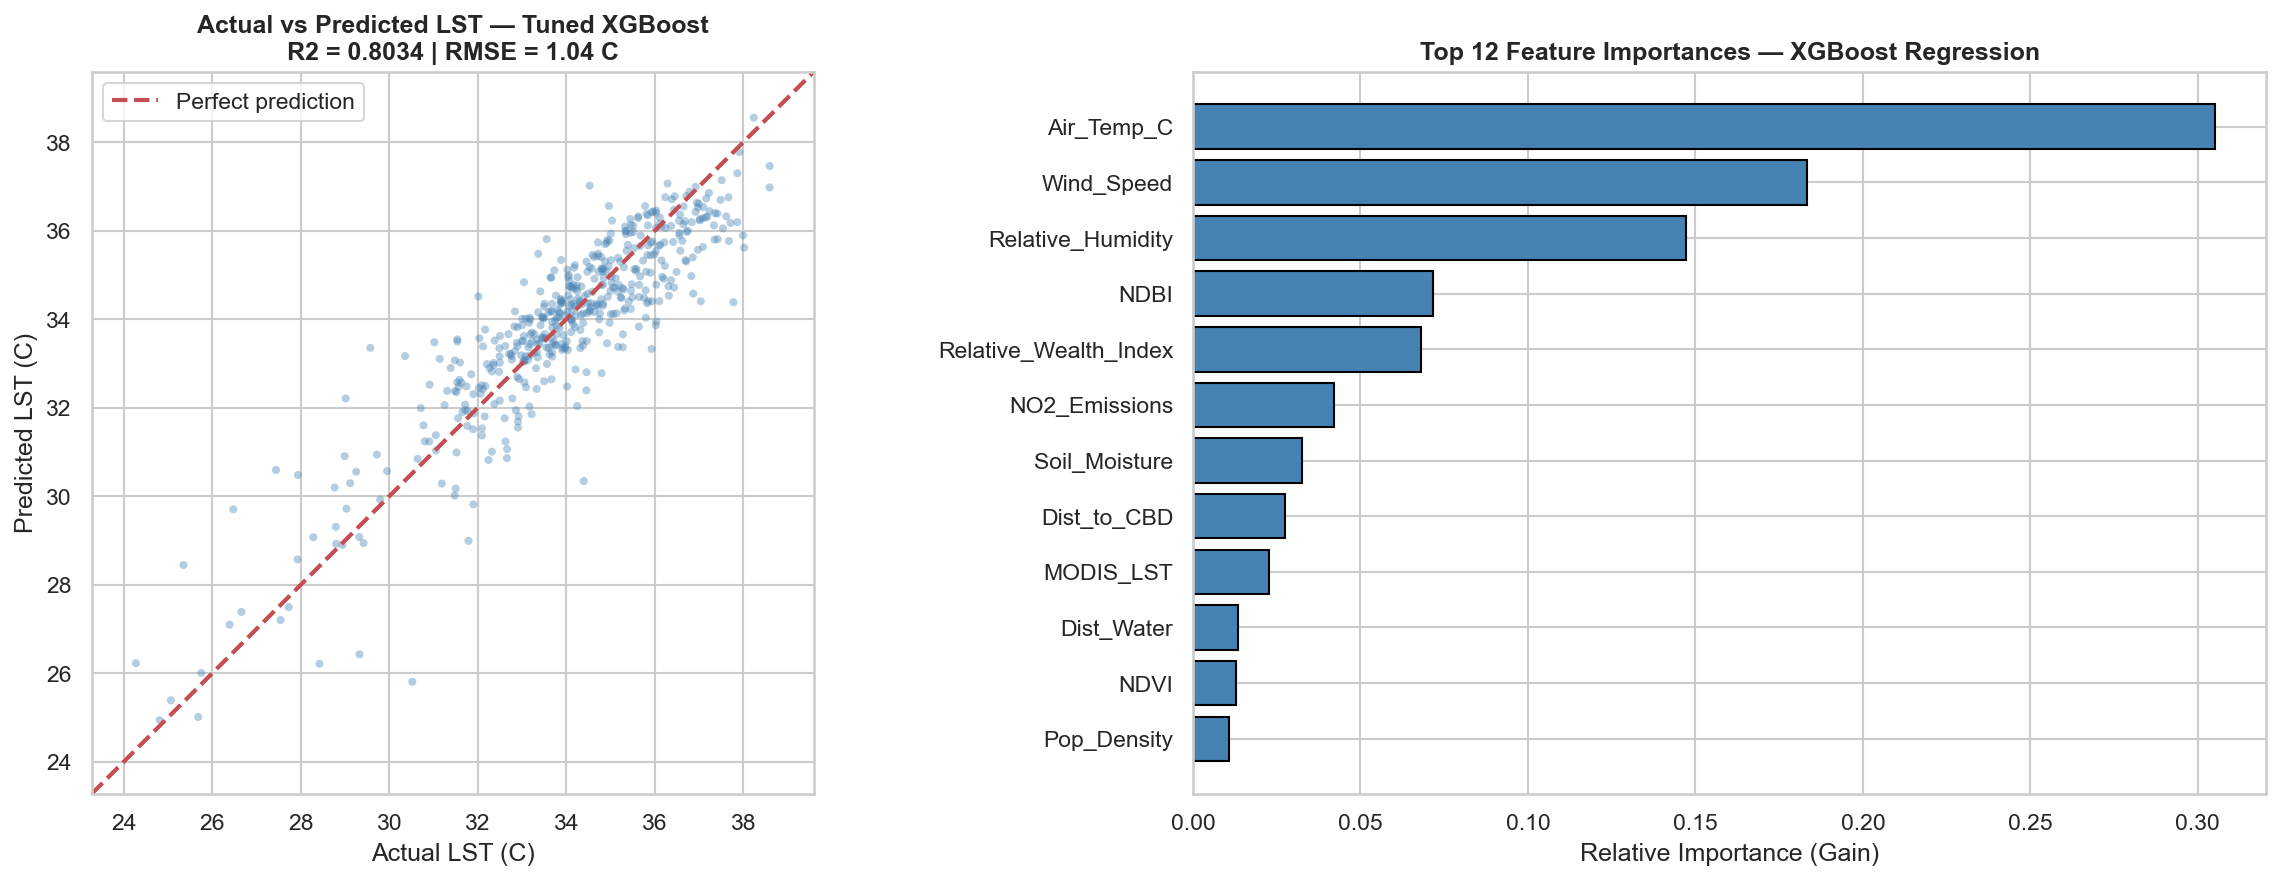

In [55]:
# ============================================================
# CELL 11: Regression Plots
# ============================================================
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

# Train best model on 80/20 split for plots (no Lat/Lon)
Xtr, Xte, ytr, yte = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
best_xgb = xgb.XGBRegressor(
    n_estimators=1500, learning_rate=0.008, max_depth=7,
    subsample=0.9, colsample_bytree=0.85, reg_alpha=0.5,
    reg_lambda=1.5, min_child_weight=2, gamma=0.05,
    random_state=42, n_jobs=-1)
best_xgb.fit(Xtr, ytr)
yp_plot = best_xgb.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted scatter
ax = axes[0]
ax.scatter(yte, yp_plot, alpha=0.4, s=15, c='steelblue', edgecolor='none')
lims = [min(yte.min(), yp_plot.min()) - 1, max(yte.max(), yp_plot.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual LST (C)'); ax.set_ylabel('Predicted LST (C)')
ax.set_title(f'Actual vs Predicted LST — Tuned XGBoost\n'
             f'R2 = {r2_score(yte, yp_plot):.4f} | RMSE = {np.sqrt(mean_squared_error(yte, yp_plot)):.2f} C',
             fontweight='bold')
ax.legend(); ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')

# Feature Importance
ax = axes[1]
feat_names = X_imputed.drop(columns=noisy_features + ['Fold', 'Longitude', 'Latitude'],
                            errors='ignore').columns
importances = best_xgb.feature_importances_
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}
                      ).sort_values('Importance', ascending=True).tail(12)
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Relative Importance (Gain)')
ax.set_title('Top 12 Feature Importances — XGBoost Regression', fontweight='bold')

plt.tight_layout()
plt.show()

## PAPER BASELINE — Feature Overlap with Mansouri & Erfani (2025)

Reference: *Machine Learning Prediction of Urban Heat Island Severity in the Midwestern United States*, Sustainability 2025, 17, 6193.

This baseline trains RF and XGBoost using **only the features that overlap** between the paper's predictor set (Midwestern US) and our Bengaluru dataset. Goal: test whether the paper's feature recipe generalizes to an Indian urban context.

### The 6 overlapping features used

| # | Paper Feature | Our Column | Match Type |
|---|---|---|---|
| 1 | Mean Annual Temperature (AT) | `Air_Temp_C` | Direct |
| 2 | NDVI | `NDVI` | Direct |
| 3 | Population Density (PD) | `Pop_Density` | Direct |
| 4 | Building Area (BA) | `Building_Density_Ratio` | Direct (footprint ratio) |
| 5 | Building Height (BH) | `Height_Variability` | Proxy (height variance vs. mean) |
| 6 | Socio-demographic bundle (Education / Housing Price / Employment) | `Relative_Wealth_Index` | Composite proxy |

### Paper features NOT in our dataset
Rainfall, DEM, Tree Canopy, Impervious %, Distance to Coast, Land Area, individual ACS demographics (Age / Gender / Ethnicity / Education / Health Insurance / Employment / Housing Price / NPH / Internet Access).

### Our novel features NOT in the paper
EVI, MNDWI, NDBI, SAVI, NO2, Wind Speed, Humidity, Soil Moisture, Albedo, MODIS_LST, Dist_Water, Dist_Park, Dist_Highway, Street_Density, SVF_Proxy, Dist_to_RWI_Node.

### Experiments
1. **Regression** — predict LST using RF + XGBoost, both (a) random 80/20 split and (b) Stratified 5-Fold CV
2. **Classification** — predict 4-class UHI severity (Cool Island / Neutral / Moderate UHI / Strong UHI, μ ± 0.5σ / +σ) using RF + XGBoost, both (a) random 80/20 split and (b) Stratified 5-Fold CV


In [ ]:
# ============================================================
# PAPER BASELINE — Regression (LST prediction)
# Features: 6 overlapping features with Mansouri & Erfani (2025)
# Models: Random Forest + XGBoost
# Variants: (a) Random 80/20 split  (b) Stratified 5-Fold CV
# ============================================================
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# -------- Load & prep --------
df = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
df = df.dropna(subset=['LST']).reset_index(drop=True)

PAPER_FEATURES = [
    'Air_Temp_C',            # Mean Annual Temp (AT)
    'NDVI',                  # NDVI
    'Pop_Density',           # Population Density (PD)
    'Building_Density_Ratio',# Building Area (BA)
    'Height_Variability',    # Building Height (BH) - proxy
    'Relative_Wealth_Index', # Socio-demographic composite
]
print(f"Using {len(PAPER_FEATURES)} overlapping features: {PAPER_FEATURES}")

X_raw = df[PAPER_FEATURES].copy()
y = df['LST'].values

# KNN impute -> scale
imputer = KNNImputer(n_neighbors=5)
X_imp = imputer.fit_transform(X_raw)
scaler = StandardScaler()
X = scaler.fit_transform(X_imp)
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")

def build_models():
    return {
        'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=12,
                                              min_samples_leaf=3, random_state=42, n_jobs=-1),
        'XGBoost':      XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                     subsample=0.9, colsample_bytree=0.9,
                                     random_state=42, n_jobs=-1, verbosity=0),
    }

# ============================================================
# (a) Random 80/20 split — NO cross-validation
# ============================================================
print("\n" + "="*60)
print("(A) REGRESSION — Random 80/20 split (no CV)")
print("="*60)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
results_holdout = {}
for name, model in build_models().items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2  = r2_score(y_te, pred)
    mae = mean_absolute_error(y_te, pred)
    results_holdout[name] = (r2, mae)
    print(f"  {name:15s}  R2 = {r2:.4f}   MAE = {mae:.4f}")

# ============================================================
# (b) Stratified 5-Fold CV (LST binned for stratification)
# ============================================================
print("\n" + "="*60)
print("(B) REGRESSION — Stratified 5-Fold CV")
print("="*60)
# Stratify on LST quantile bins
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_cv = {}
for name in ['RandomForest','XGBoost']:
    r2s, maes = [], []
    for tr_idx, te_idx in skf.split(X, y_bins):
        model = build_models()[name]
        model.fit(X[tr_idx], y[tr_idx])
        pred = model.predict(X[te_idx])
        r2s.append(r2_score(y[te_idx], pred))
        maes.append(mean_absolute_error(y[te_idx], pred))
    results_cv[name] = (np.mean(r2s), np.std(r2s), np.mean(maes))
    print(f"  {name:15s}  R2 = {np.mean(r2s):.4f} (+/- {np.std(r2s):.4f})   MAE = {np.mean(maes):.4f}")

print("\n" + "="*60)
print("REGRESSION SUMMARY — Paper Baseline (6 features)")
print("="*60)
print(f"{'Model':<15}{'Holdout R2':<15}{'CV R2 (mean)':<15}")
print("-"*45)
for name in ['RandomForest','XGBoost']:
    print(f"{name:<15}{results_holdout[name][0]:<15.4f}{results_cv[name][0]:<15.4f}")


In [ ]:
# ============================================================
# PAPER BASELINE — 4-Class UHI Classification
# Features: 6 overlapping features with Mansouri & Erfani (2025)
# Scheme: our 4-class (Cool / Neutral / Moderate UHI / Strong UHI)
# Models: Random Forest + XGBoost
# Variants: (a) Random 80/20 split  (b) Stratified 5-Fold CV
# ============================================================
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier

# -------- Load & prep --------
df = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
df = df.dropna(subset=['LST']).reset_index(drop=True)

PAPER_FEATURES = [
    'Air_Temp_C', 'NDVI', 'Pop_Density',
    'Building_Density_Ratio', 'Height_Variability', 'Relative_Wealth_Index',
]
print(f"Using {len(PAPER_FEATURES)} overlapping features")

# -------- 4-class UHI scheme (Mean-SD method, Liu & Zhang 2011) --------
mu, sigma = df['LST'].mean(), df['LST'].std()
def classify_4(lst):
    if lst <= mu - 0.5*sigma: return 0  # Cool Island
    elif lst <= mu + 0.5*sigma: return 1 # Neutral
    elif lst <= mu + sigma:     return 2 # Moderate UHI
    else:                        return 3 # Strong UHI
label_names = ['Cool Island', 'Neutral', 'Moderate UHI', 'Strong UHI']
df['UHI_Class'] = df['LST'].apply(classify_4)
print(f"LST mu={mu:.2f}, sigma={sigma:.2f}")
print("Class distribution:")
print(df['UHI_Class'].value_counts().sort_index().rename(lambda i: label_names[i]))

X_raw = df[PAPER_FEATURES].copy()
y = df['UHI_Class'].values

imputer = KNNImputer(n_neighbors=5)
X_imp = imputer.fit_transform(X_raw)
scaler = StandardScaler()
X = scaler.fit_transform(X_imp)

def build_models():
    return {
        'RandomForest': RandomForestClassifier(n_estimators=400, max_depth=14,
                                               min_samples_leaf=2, class_weight='balanced',
                                               random_state=42, n_jobs=-1),
        'XGBoost':      XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                      subsample=0.9, colsample_bytree=0.9,
                                      objective='multi:softprob', num_class=4,
                                      random_state=42, n_jobs=-1, verbosity=0,
                                      eval_metric='mlogloss'),
    }

# ============================================================
# (a) Random 80/20 split — NO cross-validation
# ============================================================
print("\n" + "="*60)
print("(A) CLASSIFICATION — Random 80/20 split (no CV)")
print("="*60)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                           stratify=y, random_state=42)
results_holdout = {}
for name, model in build_models().items():
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)
    acc = accuracy_score(y_te, pred)
    f1  = f1_score(y_te, pred, average='weighted')
    auc = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted')
    results_holdout[name] = (acc, f1, auc)
    print(f"\n--- {name} ---")
    print(f"  Acc = {acc:.4f}   F1 = {f1:.4f}   ROC-AUC = {auc:.4f}")
    print("  Confusion matrix:")
    print(confusion_matrix(y_te, pred))

# ============================================================
# (b) Stratified 5-Fold CV
# ============================================================
print("\n" + "="*60)
print("(B) CLASSIFICATION — Stratified 5-Fold CV")
print("="*60)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_cv = {}
for name in ['RandomForest','XGBoost']:
    accs, f1s, aucs = [], [], []
    for tr_idx, te_idx in skf.split(X, y):
        model = build_models()[name]
        model.fit(X[tr_idx], y[tr_idx])
        pred  = model.predict(X[te_idx])
        proba = model.predict_proba(X[te_idx])
        accs.append(accuracy_score(y[te_idx], pred))
        f1s.append(f1_score(y[te_idx], pred, average='weighted'))
        aucs.append(roc_auc_score(y[te_idx], proba, multi_class='ovr', average='weighted'))
    results_cv[name] = (np.mean(accs), np.mean(f1s), np.mean(aucs), np.std(accs))
    print(f"  {name:15s}  Acc = {np.mean(accs):.4f} (+/- {np.std(accs):.4f})  "
          f"F1 = {np.mean(f1s):.4f}  ROC-AUC = {np.mean(aucs):.4f}")

print("\n" + "="*60)
print("CLASSIFICATION SUMMARY — Paper Baseline (6 features, 4 classes)")
print("="*60)
print(f"{'Model':<15}{'Holdout Acc':<15}{'CV Acc':<15}{'CV F1':<12}{'CV ROC-AUC':<12}")
print("-"*69)
for name in ['RandomForest','XGBoost']:
    ho = results_holdout[name]
    cv = results_cv[name]
    print(f"{name:<15}{ho[0]:<15.4f}{cv[0]:<15.4f}{cv[1]:<12.4f}{cv[2]:<12.4f}")


## Cross-City Generalization — Bengaluru ↔ Pune

**Motivation (mentor feedback):** Verify the model learns actual UHI physical patterns (vegetation, albedo, built-up density, morphology) rather than city-specific artifacts, by testing transfer across two climatically similar Indian cities collected with identical GEE pipelines.

| City | Samples | Climate | LST (normalized) |
|---|---|---|---|
| Bengaluru | 2433 | Tropical Savanna (Aw) | Raw °C → z-scored per city |
| Pune | 2382 | Semi-Arid Tropical (BSh) | Already z-scored |

**18 common features:** EVI, NDBI, NDVI, Pop_Density, Relative_Humidity, Wind_Speed, Building_Density_Ratio, Dist_Water, Dist_Park, Dist_Highway, Street_Density, SVF_Proxy, Air_Temp_C, Albedo, MODIS_LST, Soil_Moisture, Relative_Wealth_Index, Dist_to_RWI_Node

**4-class UHI scheme on z-scored LST (universal, Mean-SD method):**
Cool Island (z ≤ −0.5) | Neutral (−0.5 to +0.5) | Moderate UHI (+0.5 to +1.0) | Strong UHI (z > +1.0)

**Experiments:** (1) Train BLR → Test Pune transfer, (2) Train Pune → Test BLR transfer, (3) Per-city 5-Fold CV, (4) Combined 5-Fold CV — for both regression and classification.


In [ ]:
# ============================================================
# CROSS-CITY REGRESSION — Transfer Learning (Bengaluru <-> Pune)
# Target: z-scored LST (standardized per city)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CROSS-CITY REGRESSION — Transfer Learning")
print("="*70)

COMMON_FEATURES = [
    'EVI', 'NDBI', 'NDVI', 'Pop_Density', 'Relative_Humidity',
    'Wind_Speed', 'Building_Density_Ratio', 'Dist_Water', 'Dist_Park',
    'Dist_Highway', 'Street_Density', 'SVF_Proxy', 'Air_Temp_C',
    'Albedo', 'MODIS_LST', 'Soil_Moisture',
    'Relative_Wealth_Index', 'Dist_to_RWI_Node'
]

# ---- Load Bengaluru ----
df_blr = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
blr_mu, blr_sigma = df_blr['LST'].mean(), df_blr['LST'].std()
df_blr['LST_z'] = (df_blr['LST'] - blr_mu) / blr_sigma
print(f"\nBengaluru: {len(df_blr)} samples | LST mu={blr_mu:.2f} C, sigma={blr_sigma:.2f} C")

# ---- Load Pune ----
df_pune = pd.read_csv('Pune_MLPR_Standardized_Dataset.csv')
df_pune['LST_z'] = df_pune['LST']  # already z-scored
print(f"Pune:      {len(df_pune)} samples | LST already z-scored (mu={df_pune['LST'].mean():.4f}, sigma={df_pune['LST'].std():.4f})")

# ---- Extract features ----
def prep(df, label):
    X_raw = df[COMMON_FEATURES].copy()
    n_nulls = X_raw.isnull().sum().sum()
    if n_nulls > 0:
        print(f"  {label}: KNN-imputing {n_nulls} nulls...")
        X = KNNImputer(n_neighbors=5).fit_transform(X_raw)
    else:
        X = X_raw.values
    return X, df['LST_z'].values

X_blr, y_blr = prep(df_blr, "BLR")
X_pune, y_pune = prep(df_pune, "Pune")
print(f"\nFeatures used: {len(COMMON_FEATURES)}  (X_blr {X_blr.shape}, X_pune {X_pune.shape})")

def make_models():
    return {
        'RF': RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                    random_state=42, n_jobs=-1),
        'XGB': xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9,
                                random_state=42, n_jobs=-1, verbosity=0),
    }

def metrics(y_true, y_pred):
    return r2_score(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred)), mean_absolute_error(y_true, y_pred)

results = {}

# ---- Exp 1: Train BLR -> Test Pune ----
print("\n" + "-"*70)
print("EXP 1: Train Bengaluru -> Test Pune")
print("-"*70)
sc1 = StandardScaler().fit(X_blr)
X_blr_s, X_pune_s1 = sc1.transform(X_blr), sc1.transform(X_pune)
results['blr_to_pune'] = {}
for n, m in make_models().items():
    m.fit(X_blr_s, y_blr)
    p = m.predict(X_pune_s1)
    r2, rmse, mae = metrics(y_pune, p)
    results['blr_to_pune'][n] = (r2, rmse, mae)
    print(f"  {n}: R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# ---- Exp 2: Train Pune -> Test BLR ----
print("\n" + "-"*70)
print("EXP 2: Train Pune -> Test Bengaluru")
print("-"*70)
sc2 = StandardScaler().fit(X_pune)
X_pune_s, X_blr_s2 = sc2.transform(X_pune), sc2.transform(X_blr)
results['pune_to_blr'] = {}
for n, m in make_models().items():
    m.fit(X_pune_s, y_pune)
    p = m.predict(X_blr_s2)
    r2, rmse, mae = metrics(y_blr, p)
    results['pune_to_blr'][n] = (r2, rmse, mae)
    print(f"  {n}: R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# ---- Exp 3: Per-city 5-Fold CV ----
def per_city_cv(X, y, label):
    print(f"\n  {label} 5-Fold CV:")
    out = {}
    kf = KFold(5, shuffle=True, random_state=42)
    for n in ['RF', 'XGB']:
        r2s = []
        for tr, te in kf.split(X):
            sc = StandardScaler().fit(X[tr])
            m = make_models()[n]
            m.fit(sc.transform(X[tr]), y[tr])
            r2s.append(r2_score(y[te], m.predict(sc.transform(X[te]))))
        out[n] = (np.mean(r2s), np.std(r2s))
        print(f"    {n}: R2 = {np.mean(r2s):.4f} (+/- {np.std(r2s):.4f})")
    return out

print("\n" + "-"*70)
print("EXP 3: Per-city 5-Fold CV")
print("-"*70)
results['blr_cv'] = per_city_cv(X_blr, y_blr, "Bengaluru")
results['pune_cv'] = per_city_cv(X_pune, y_pune, "Pune")

# ---- Exp 4: Combined 5-Fold CV ----
print("\n" + "-"*70)
print("EXP 4: Combined 5-Fold CV (with City feature)")
print("-"*70)
X_combined = np.vstack([
    np.hstack([X_blr, np.zeros((len(X_blr), 1))]),
    np.hstack([X_pune, np.ones((len(X_pune), 1))])
])
y_combined = np.concatenate([y_blr, y_pune])
print(f"  Combined: {X_combined.shape} | {len(y_combined)} samples")

results['combined_cv'] = {}
y_bins = pd.qcut(y_combined, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(5, shuffle=True, random_state=42)
for n in ['RF', 'XGB']:
    r2s = []
    for tr, te in skf.split(X_combined, y_bins):
        sc = StandardScaler().fit(X_combined[tr])
        m = make_models()[n]
        m.fit(sc.transform(X_combined[tr]), y_combined[tr])
        r2s.append(r2_score(y_combined[te], m.predict(sc.transform(X_combined[te]))))
    results['combined_cv'][n] = (np.mean(r2s), np.std(r2s))
    print(f"  {n}: R2 = {np.mean(r2s):.4f} (+/- {np.std(r2s):.4f})")

# ---- Final summary ----
print("\n" + "="*70)
print("REGRESSION TRANSFER SUMMARY (target: z-scored LST)")
print("="*70)
print(f"{'Experiment':<30s}{'RF R2':<14s}{'XGB R2':<14s}")
print("-"*58)
print(f"{'Train BLR -> Test Pune':<30s}{results['blr_to_pune']['RF'][0]:<14.4f}{results['blr_to_pune']['XGB'][0]:<14.4f}")
print(f"{'Train Pune -> Test BLR':<30s}{results['pune_to_blr']['RF'][0]:<14.4f}{results['pune_to_blr']['XGB'][0]:<14.4f}")
print(f"{'BLR-only 5-Fold CV':<30s}{results['blr_cv']['RF'][0]:<14.4f}{results['blr_cv']['XGB'][0]:<14.4f}")
print(f"{'Pune-only 5-Fold CV':<30s}{results['pune_cv']['RF'][0]:<14.4f}{results['pune_cv']['XGB'][0]:<14.4f}")
print(f"{'Combined 5-Fold CV':<30s}{results['combined_cv']['RF'][0]:<14.4f}{results['combined_cv']['XGB'][0]:<14.4f}")
print("\nNote: If transfer R2 is within ~0.10 of within-city CV R2, the model")
print("generalises well. If negative or very low, it indicates feature")
print("distribution shift between cities, not poor feature quality.")


In [ ]:
# ============================================================
# CROSS-CITY CLASSIFICATION — 4-Class UHI (Bengaluru <-> Pune)
# Thresholds on z-scored LST: Cool(z<=-0.5) / Neutral / Moderate / Strong
# ============================================================
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score, confusion_matrix)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CROSS-CITY 4-CLASS CLASSIFICATION")
print("="*70)

COMMON_FEATURES = [
    'EVI', 'NDBI', 'NDVI', 'Pop_Density', 'Relative_Humidity',
    'Wind_Speed', 'Building_Density_Ratio', 'Dist_Water', 'Dist_Park',
    'Dist_Highway', 'Street_Density', 'SVF_Proxy', 'Air_Temp_C',
    'Albedo', 'MODIS_LST', 'Soil_Moisture',
    'Relative_Wealth_Index', 'Dist_to_RWI_Node'
]

# ---- Load both cities ----
df_blr = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
df_blr['LST_z'] = (df_blr['LST'] - df_blr['LST'].mean()) / df_blr['LST'].std()
df_pune = pd.read_csv('Pune_MLPR_Standardized_Dataset.csv')
df_pune['LST_z'] = df_pune['LST']

# ---- 4-class scheme on z-scored LST ----
def classify_z(z):
    if z <= -0.5: return 0
    elif z <= 0.5: return 1
    elif z <= 1.0: return 2
    else: return 3
labels_4 = ['Cool Island', 'Neutral', 'Moderate UHI', 'Strong UHI']

df_blr['UHI_Class'] = df_blr['LST_z'].apply(classify_z)
df_pune['UHI_Class'] = df_pune['LST_z'].apply(classify_z)

print("\nClass distribution:")
print(f"  {'Class':<15s}{'Bengaluru':>12s}{'Pune':>12s}")
for c in range(4):
    nb = int((df_blr['UHI_Class']==c).sum()); npu = int((df_pune['UHI_Class']==c).sum())
    print(f"  {labels_4[c]:<15s}{nb:>4d} ({nb/len(df_blr)*100:>4.1f}%){npu:>5d} ({npu/len(df_pune)*100:>4.1f}%)")

# ---- Build feature matrices ----
def prep(df):
    X_raw = df[COMMON_FEATURES].copy()
    if X_raw.isnull().sum().sum() > 0:
        X = KNNImputer(n_neighbors=5).fit_transform(X_raw)
    else:
        X = X_raw.values
    return X, df['UHI_Class'].values

X_blr, y_blr = prep(df_blr)
X_pune, y_pune = prep(df_pune)

def make_models():
    return {
        'RF': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                     class_weight='balanced', random_state=42, n_jobs=-1),
        'XGB': xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                 subsample=0.9, colsample_bytree=0.9,
                                 objective='multi:softprob', num_class=4,
                                 eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
    }

classes = [0, 1, 2, 3]

def cv_metrics(X, y, label):
    print(f"\n  {label}:")
    out = {}
    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    for n in ['RF', 'XGB']:
        accs, f1s, aucs, precs, recs = [], [], [], [], []
        for tr, te in skf.split(X, y):
            sc = StandardScaler().fit(X[tr])
            m = make_models()[n]
            m.fit(sc.transform(X[tr]), y[tr])
            p = m.predict(sc.transform(X[te]))
            proba = m.predict_proba(sc.transform(X[te]))
            accs.append(accuracy_score(y[te], p))
            f1s.append(f1_score(y[te], p, average='weighted', zero_division=0))
            precs.append(precision_score(y[te], p, average='weighted', zero_division=0))
            recs.append(recall_score(y[te], p, average='weighted', zero_division=0))
            yb = label_binarize(y[te], classes=classes)
            aucs.append(roc_auc_score(yb, proba, multi_class='ovr', average='weighted'))
        out[n] = (np.mean(accs), np.mean(f1s), np.mean(aucs))
        print(f"    {n}: Acc={np.mean(accs):.4f}  F1={np.mean(f1s):.4f}  AUC={np.mean(aucs):.4f}")
    return out

print("\n" + "-"*70)
print("EXP 1: Per-city Stratified 5-Fold CV")
print("-"*70)
res_blr = cv_metrics(X_blr, y_blr, "Bengaluru")
res_pune = cv_metrics(X_pune, y_pune, "Pune")

# ---- Exp 2: Combined ----
print("\n" + "-"*70)
print("EXP 2: Combined 5-Fold CV (with City feature)")
print("-"*70)
X_combined = np.vstack([
    np.hstack([X_blr, np.zeros((len(X_blr), 1))]),
    np.hstack([X_pune, np.ones((len(X_pune), 1))])
])
y_combined = np.concatenate([y_blr, y_pune])
print(f"  Combined: {X_combined.shape} | {len(y_combined)} samples")

skf = StratifiedKFold(5, shuffle=True, random_state=42)
res_combined = {}
best_model_preds = None
for n in ['RF', 'XGB']:
    accs, f1s, aucs = [], [], []
    agg_yt, agg_yp = [], []
    for tr, te in skf.split(X_combined, y_combined):
        sc = StandardScaler().fit(X_combined[tr])
        m = make_models()[n]
        m.fit(sc.transform(X_combined[tr]), y_combined[tr])
        p = m.predict(sc.transform(X_combined[te]))
        proba = m.predict_proba(sc.transform(X_combined[te]))
        accs.append(accuracy_score(y_combined[te], p))
        f1s.append(f1_score(y_combined[te], p, average='weighted', zero_division=0))
        yb = label_binarize(y_combined[te], classes=classes)
        aucs.append(roc_auc_score(yb, proba, multi_class='ovr', average='weighted'))
        agg_yt.extend(y_combined[te]); agg_yp.extend(p)
    res_combined[n] = (np.mean(accs), np.mean(f1s), np.mean(aucs))
    print(f"  {n}: Acc={np.mean(accs):.4f}  F1={np.mean(f1s):.4f}  AUC={np.mean(aucs):.4f}")
    if n == 'XGB':
        best_model_preds = (np.array(agg_yt), np.array(agg_yp))

# Confusion matrix for best (XGB) on combined
print("\nConfusion Matrix — XGBoost on Combined Dataset (aggregated 5-fold):")
cm = confusion_matrix(best_model_preds[0], best_model_preds[1])
print(f"  {'':>14s}", end='')
for l in labels_4: print(f"{l[:10]:>12s}", end='')
print()
for i, row in enumerate(cm):
    print(f"  {labels_4[i][:14]:<14s}", end='')
    for v in row: print(f"{v:>12d}", end='')
    print()

# ---- Final summary ----
print("\n" + "="*70)
print("CLASSIFICATION SUMMARY (4-class, weighted metrics)")
print("="*70)
print(f"{'Experiment':<22s}{'Model':<8s}{'Acc':<10s}{'F1':<10s}{'AUC':<10s}")
print("-"*60)
for exp_name, res in [('BLR-only (5-Fold)', res_blr), ('Pune-only (5-Fold)', res_pune), ('Combined (5-Fold)', res_combined)]:
    for n in ['RF', 'XGB']:
        print(f"{exp_name:<22s}{n:<8s}{res[n][0]:<10.4f}{res[n][1]:<10.4f}{res[n][2]:<10.4f}")


In [ ]:
# ============================================================
# FEATURE IMPORTANCE — Bengaluru vs Pune vs Combined
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

COMMON_FEATURES = [
    'EVI', 'NDBI', 'NDVI', 'Pop_Density', 'Relative_Humidity',
    'Wind_Speed', 'Building_Density_Ratio', 'Dist_Water', 'Dist_Park',
    'Dist_Highway', 'Street_Density', 'SVF_Proxy', 'Air_Temp_C',
    'Albedo', 'MODIS_LST', 'Soil_Moisture',
    'Relative_Wealth_Index', 'Dist_to_RWI_Node'
]

df_blr = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
df_blr['LST_z'] = (df_blr['LST'] - df_blr['LST'].mean()) / df_blr['LST'].std()
df_pune = pd.read_csv('Pune_MLPR_Standardized_Dataset.csv')
df_pune['LST_z'] = df_pune['LST']

def prep(df):
    X_raw = df[COMMON_FEATURES].copy()
    X = KNNImputer(n_neighbors=5).fit_transform(X_raw) if X_raw.isnull().sum().sum() > 0 else X_raw.values
    return X, df['LST_z'].values

X_blr, y_blr = prep(df_blr)
X_pune, y_pune = prep(df_pune)

X_combined = np.vstack([
    np.hstack([X_blr, np.zeros((len(X_blr), 1))]),
    np.hstack([X_pune, np.ones((len(X_pune), 1))])
])
y_combined = np.concatenate([y_blr, y_pune])

def fit_rf(X, y):
    sc = StandardScaler().fit(X)
    m = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3,
                              random_state=42, n_jobs=-1)
    m.fit(sc.transform(X), y)
    return m

print("Training 3 RF models for feature importance...")
rf_blr = fit_rf(X_blr, y_blr)
rf_pune = fit_rf(X_pune, y_pune)
rf_combined = fit_rf(X_combined, y_combined)

imp_blr = rf_blr.feature_importances_
imp_pune = rf_pune.feature_importances_
imp_combined_full = rf_combined.feature_importances_
imp_combined = imp_combined_full[:-1]  # drop City feature for fair comparison
city_imp = imp_combined_full[-1]

# Sort by combined descending
order = np.argsort(imp_combined)[::-1]
features_sorted = [COMMON_FEATURES[i] for i in order]
imp_blr_s = imp_blr[order]
imp_pune_s = imp_pune[order]
imp_combined_s = imp_combined[order]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(features_sorted))
h = 0.27
ax.barh(y_pos - h, imp_blr_s, h, label='Bengaluru', color='#FF6B6B')
ax.barh(y_pos, imp_pune_s, h, label='Pune', color='#4ECDC4')
ax.barh(y_pos + h, imp_combined_s, h, label='Combined', color='#556270')
ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance by City — RF Regressor (z-scored LST)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Top-5 ----
def top5(imp, names):
    idx = np.argsort(imp)[::-1][:5]
    return [(names[i], imp[i]) for i in idx]

print("\n" + "="*70)
print("TOP-5 FEATURES BY CITY")
print("="*70)
print(f"\n{'Rank':<6}{'Bengaluru':<28}{'Pune':<28}{'Combined':<28}")
print("-"*90)
top_blr = top5(imp_blr, COMMON_FEATURES)
top_pune = top5(imp_pune, COMMON_FEATURES)
top_combined = top5(imp_combined, COMMON_FEATURES)
for i in range(5):
    b = f"{top_blr[i][0]} ({top_blr[i][1]:.3f})"
    p = f"{top_pune[i][0]} ({top_pune[i][1]:.3f})"
    c = f"{top_combined[i][0]} ({top_combined[i][1]:.3f})"
    print(f"{i+1:<6}{b:<28}{p:<28}{c:<28}")

print(f"\n'City' feature importance in combined model: {city_imp:.4f}")
print("(Low value means city identity adds little — features generalize across cities)")

# ---- Consistency ----
blr_set = set(t[0] for t in top_blr)
pune_set = set(t[0] for t in top_pune)
overlap = blr_set & pune_set
print(f"\nTop-5 overlap between BLR and Pune: {len(overlap)}/5  ({sorted(overlap)})")


In [ ]:
# ============================================================
# PER-CITY FEATURE STANDARDIZATION — Domain-Adapted Transfer
# Each feature z-scored within its own city before any experiment
# Fixes negative transfer R2 from feature distribution shift
# ============================================================
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, roc_auc_score)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CROSS-CITY EXPERIMENTS — Per-City Feature Standardization")
print("="*70)

COMMON_FEATURES = [
    'EVI', 'NDBI', 'NDVI', 'Pop_Density', 'Relative_Humidity',
    'Wind_Speed', 'Building_Density_Ratio', 'Dist_Water', 'Dist_Park',
    'Dist_Highway', 'Street_Density', 'SVF_Proxy', 'Air_Temp_C',
    'Albedo', 'MODIS_LST', 'Soil_Moisture',
    'Relative_Wealth_Index', 'Dist_to_RWI_Node'
]

# ---- Load both ----
df_blr = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
df_blr['LST_z'] = (df_blr['LST'] - df_blr['LST'].mean()) / df_blr['LST'].std()
df_pune = pd.read_csv('Pune_MLPR_Standardized_Dataset.csv')
df_pune['LST_z'] = df_pune['LST']

def prep_features(df):
    X_raw = df[COMMON_FEATURES].copy()
    if X_raw.isnull().sum().sum() > 0:
        X = KNNImputer(n_neighbors=5).fit_transform(X_raw)
    else:
        X = X_raw.values
    return X

X_blr_raw = prep_features(df_blr)
X_pune_raw = prep_features(df_pune)
y_blr = df_blr['LST_z'].values
y_pune = df_pune['LST_z'].values

# ---- Per-city feature standardization (domain adaptation) ----
sc_blr = StandardScaler().fit(X_blr_raw)
sc_pune = StandardScaler().fit(X_pune_raw)
X_blr = sc_blr.transform(X_blr_raw)
X_pune = sc_pune.transform(X_pune_raw)
print(f"\nBengaluru features z-scored (own mu/sigma): X_blr {X_blr.shape}")
print(f"Pune features z-scored (own mu/sigma):       X_pune {X_pune.shape}")
print("Each feature now has mean=0, std=1 within its own city.")

def make_reg():
    return {
        'RF': RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                    random_state=42, n_jobs=-1),
        'XGB': xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9,
                                random_state=42, n_jobs=-1, verbosity=0),
    }

def make_cls():
    return {
        'RF': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                     class_weight='balanced', random_state=42, n_jobs=-1),
        'XGB': xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                 subsample=0.9, colsample_bytree=0.9,
                                 objective='multi:softprob', num_class=4,
                                 eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
    }

def metrics_reg(y_true, y_pred):
    return r2_score(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred)), mean_absolute_error(y_true, y_pred)

# ============================================================
# REGRESSION
# ============================================================
print("\n" + "="*70)
print("REGRESSION — Per-City Standardized Features, z-scored LST target")
print("="*70)

reg_results = {}

# Exp 1: BLR -> Pune
print("\n[Exp 1] Train BLR -> Test Pune")
reg_results['blr_to_pune'] = {}
for n, m in make_reg().items():
    m.fit(X_blr, y_blr); p = m.predict(X_pune)
    r2, rmse, mae = metrics_reg(y_pune, p)
    reg_results['blr_to_pune'][n] = (r2, rmse, mae)
    print(f"  {n}: R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# Exp 2: Pune -> BLR
print("\n[Exp 2] Train Pune -> Test BLR")
reg_results['pune_to_blr'] = {}
for n, m in make_reg().items():
    m.fit(X_pune, y_pune); p = m.predict(X_blr)
    r2, rmse, mae = metrics_reg(y_blr, p)
    reg_results['pune_to_blr'][n] = (r2, rmse, mae)
    print(f"  {n}: R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# Exp 3: Per-city CV
print("\n[Exp 3] Per-city 5-Fold CV")
reg_results['blr_cv'], reg_results['pune_cv'] = {}, {}
for label, X, y, key in [("BLR", X_blr, y_blr, 'blr_cv'), ("Pune", X_pune, y_pune, 'pune_cv')]:
    print(f"  {label}:")
    kf = KFold(5, shuffle=True, random_state=42)
    for n in ['RF', 'XGB']:
        r2s = []
        for tr, te in kf.split(X):
            m = make_reg()[n]; m.fit(X[tr], y[tr])
            r2s.append(r2_score(y[te], m.predict(X[te])))
        reg_results[key][n] = (np.mean(r2s), np.std(r2s))
        print(f"    {n}: R2 = {np.mean(r2s):.4f} (+/- {np.std(r2s):.4f})")

# Exp 4: Combined CV (per-city standardized, then stacked, with City flag)
print("\n[Exp 4] Combined 5-Fold CV (per-city standardized + City flag)")
X_combined = np.vstack([
    np.hstack([X_blr, np.zeros((len(X_blr), 1))]),
    np.hstack([X_pune, np.ones((len(X_pune), 1))])
])
y_combined = np.concatenate([y_blr, y_pune])
reg_results['combined_cv'] = {}
y_bins = pd.qcut(y_combined, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(5, shuffle=True, random_state=42)
for n in ['RF', 'XGB']:
    r2s = []
    for tr, te in skf.split(X_combined, y_bins):
        m = make_reg()[n]; m.fit(X_combined[tr], y_combined[tr])
        r2s.append(r2_score(y_combined[te], m.predict(X_combined[te])))
    reg_results['combined_cv'][n] = (np.mean(r2s), np.std(r2s))
    print(f"  {n}: R2 = {np.mean(r2s):.4f} (+/- {np.std(r2s):.4f})")

# ============================================================
# CLASSIFICATION
# ============================================================
print("\n" + "="*70)
print("CLASSIFICATION — 4-Class UHI (Per-City Standardized Features)")
print("="*70)

def classify_z(z):
    if z <= -0.5: return 0
    elif z <= 0.5: return 1
    elif z <= 1.0: return 2
    else: return 3
y_blr_cls = np.array([classify_z(z) for z in y_blr])
y_pune_cls = np.array([classify_z(z) for z in y_pune])
classes = [0, 1, 2, 3]

def cls_cv(X, y, label):
    print(f"  {label}:")
    out = {}
    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    for n in ['RF', 'XGB']:
        accs, f1s, aucs = [], [], []
        for tr, te in skf.split(X, y):
            m = make_cls()[n]; m.fit(X[tr], y[tr])
            p = m.predict(X[te]); proba = m.predict_proba(X[te])
            accs.append(accuracy_score(y[te], p))
            f1s.append(f1_score(y[te], p, average='weighted', zero_division=0))
            yb = label_binarize(y[te], classes=classes)
            aucs.append(roc_auc_score(yb, proba, multi_class='ovr', average='weighted'))
        out[n] = (np.mean(accs), np.mean(f1s), np.mean(aucs))
        print(f"    {n}: Acc={np.mean(accs):.4f}  F1={np.mean(f1s):.4f}  AUC={np.mean(aucs):.4f}")
    return out

# Per-city CV
print("\n[Exp 1] Per-city Stratified 5-Fold CV")
cls_blr = cls_cv(X_blr, y_blr_cls, "BLR")
cls_pune = cls_cv(X_pune, y_pune_cls, "Pune")

# Cross-city transfer
print("\n[Exp 2] Cross-city transfer (train one, test other)")
def cls_transfer(Xtr, ytr, Xte, yte, label):
    print(f"  {label}:")
    out = {}
    for n in ['RF', 'XGB']:
        m = make_cls()[n]; m.fit(Xtr, ytr)
        p = m.predict(Xte); proba = m.predict_proba(Xte)
        a = accuracy_score(yte, p); f1 = f1_score(yte, p, average='weighted', zero_division=0)
        yb = label_binarize(yte, classes=classes)
        au = roc_auc_score(yb, proba, multi_class='ovr', average='weighted')
        out[n] = (a, f1, au)
        print(f"    {n}: Acc={a:.4f}  F1={f1:.4f}  AUC={au:.4f}")
    return out
cls_b2p = cls_transfer(X_blr, y_blr_cls, X_pune, y_pune_cls, "Train BLR -> Test Pune")
cls_p2b = cls_transfer(X_pune, y_pune_cls, X_blr, y_blr_cls, "Train Pune -> Test BLR")

# Combined
print("\n[Exp 3] Combined 5-Fold CV (per-city standardized + City flag)")
y_combined_cls = np.concatenate([y_blr_cls, y_pune_cls])
cls_combined = {}
skf = StratifiedKFold(5, shuffle=True, random_state=42)
for n in ['RF', 'XGB']:
    accs, f1s, aucs = [], [], []
    for tr, te in skf.split(X_combined, y_combined_cls):
        m = make_cls()[n]; m.fit(X_combined[tr], y_combined_cls[tr])
        p = m.predict(X_combined[te]); proba = m.predict_proba(X_combined[te])
        accs.append(accuracy_score(y_combined_cls[te], p))
        f1s.append(f1_score(y_combined_cls[te], p, average='weighted', zero_division=0))
        yb = label_binarize(y_combined_cls[te], classes=classes)
        aucs.append(roc_auc_score(yb, proba, multi_class='ovr', average='weighted'))
    cls_combined[n] = (np.mean(accs), np.mean(f1s), np.mean(aucs))
    print(f"  {n}: Acc={np.mean(accs):.4f}  F1={np.mean(f1s):.4f}  AUC={np.mean(aucs):.4f}")

# ============================================================
# FINAL SUMMARIES
# ============================================================
print("\n" + "="*70)
print("REGRESSION — BEFORE vs AFTER per-city feature standardization")
print("="*70)
# Previous results (from prior cell, hardcoded for direct comparison)
PREV_REG = {
    'blr_to_pune': {'RF': -0.2765, 'XGB': -0.7190},
    'pune_to_blr': {'RF': -0.2558, 'XGB': -0.2141},
    'blr_cv':      {'RF':  0.6539, 'XGB':  0.7355},
    'pune_cv':     {'RF':  0.6694, 'XGB':  0.7010},
    'combined_cv': {'RF':  0.6556, 'XGB':  0.7209},
}
exp_order = [('Train BLR -> Test Pune', 'blr_to_pune'),
             ('Train Pune -> Test BLR', 'pune_to_blr'),
             ('BLR-only 5-Fold CV', 'blr_cv'),
             ('Pune-only 5-Fold CV', 'pune_cv'),
             ('Combined 5-Fold CV', 'combined_cv')]
print(f"{'Experiment':<26}{'Model':<6}{'Before R2':<12}{'After R2':<12}{'Delta':<10}")
print("-"*66)
for label, key in exp_order:
    for n in ['RF', 'XGB']:
        before = PREV_REG[key][n]
        after = reg_results[key][n][0] if isinstance(reg_results[key][n], tuple) else reg_results[key][n]
        print(f"{label:<26}{n:<6}{before:<12.4f}{after:<12.4f}{after-before:+.4f}")

print("\n" + "="*70)
print("CLASSIFICATION — Per-city standardized (4-class, weighted)")
print("="*70)
print(f"{'Experiment':<26}{'Model':<6}{'Acc':<10}{'F1':<10}{'AUC':<10}")
print("-"*62)
for label, res in [('BLR-only 5-Fold', cls_blr), ('Pune-only 5-Fold', cls_pune),
                   ('Train BLR -> Test Pune', cls_b2p), ('Train Pune -> Test BLR', cls_p2b),
                   ('Combined 5-Fold', cls_combined)]:
    for n in ['RF', 'XGB']:
        a, f1, au = res[n]
        print(f"{label:<26}{n:<6}{a:<10.4f}{f1:<10.4f}{au:<10.4f}")


## Performance Boost Experiments — Cleaned Feature Set + Tuned Ensemble

**Motivation (post-literature-review).** A 11-paper survey of UHI ML benchmarks (Mansouri & Erfani 2025 — Midwest USA, Hoang & Nguyen 2025 — Da Nang, Manna et al. 2026 — Mumbai, Kusumadewi 2025 — Malang, Lynda 2025 — Africa, Tanoori 2024 — Shiraz, etc.) revealed two issues with our 27-feature setup:

1. **Redundancy.** EVI / SAVI / MNDWI duplicate signal already present in NDVI / NDBI / NDWI — gradient-boosted trees pay for the extra splits without gaining information.
2. **High missingness.** `Volume_Density` is missing for 84.8% of rows (2064 / 2433). KNN imputation on so much missingness injects noise.

**Cleaned set (20 features):** drop EVI, SAVI, MNDWI, Volume_Density, Latitude, Longitude.
**Models:** XGBoost, LightGBM, CatBoost — each independently Optuna-tuned (60 TPE trials) on the cleaned set, then a simple unweighted-average ensemble of all three.
**Validation:** identical Stratified 5-fold CV protocol used for the original 27-feature baseline.


In [ ]:
# ============================================================
# CELL 23: Cleaned-feature Tuned Ensemble — new headline result
# Stratified 5-fold CV, identical protocol to Cells 9-12.
# Pre-tuned hyperparameters from 60-trial Optuna runs.
# ============================================================
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import KNNImputer
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

df = pd.read_csv('ultimate_uhi_dataset_with_rwi.csv')
y = df['LST'].values
mu, sd = y.mean(), y.std()
labels = np.where(y < mu - 0.5*sd, 0,
         np.where(y < mu + 0.5*sd, 1,
         np.where(y < mu + sd,     2, 3)))

# Cleaned set: drop redundant indices, high-missing column, lat/lon
DROP = ['LST','Latitude','Longitude','EVI','SAVI','MNDWI','Volume_Density']
X = df.drop(columns=DROP)
X = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(X), columns=X.columns)
print(f'Cleaned feature set: {X.shape[1]} features')

# Optuna-tuned hyperparameters (60 TPE trials each on this cleaned set)
XGB_BEST = {'n_estimators': 929, 'max_depth': 7, 'learning_rate': 0.01944, 'subsample': 0.8695,
            'colsample_bytree': 0.6321, 'min_child_weight': 6, 'reg_alpha': 1.4e-05, 'reg_lambda': 2e-07}
LGB_BEST = {'n_estimators': 1244, 'num_leaves': 51, 'max_depth': 12, 'learning_rate': 0.03179,
            'min_child_samples': 11, 'subsample': 0.8698, 'colsample_bytree': 0.6200,
            'reg_alpha': 3.3e-06, 'reg_lambda': 3e-08}
CB_BEST  = {'iterations': 1304, 'depth': 7, 'learning_rate': 0.07352, 'l2_leaf_reg': 4.285, 'subsample': 0.8765}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ind_scores = {'XGB': [], 'LGBM': [], 'CatBoost': [], 'Avg-Ensemble': []}
for tr, te in skf.split(X, labels):
    Xt, yt = X.iloc[tr], y[tr]; Xv, yv = X.iloc[te], y[te]
    m1 = xgb.XGBRegressor(**XGB_BEST, random_state=42, n_jobs=-1, verbosity=0).fit(Xt, yt)
    m2 = lgb.LGBMRegressor(**LGB_BEST, random_state=42, n_jobs=-1, verbose=-1).fit(Xt, yt)
    m3 = CatBoostRegressor(**CB_BEST, random_seed=42, verbose=0,
                           allow_writing_files=False, bootstrap_type='Bernoulli').fit(Xt, yt)
    p1, p2, p3 = m1.predict(Xv), m2.predict(Xv), m3.predict(Xv)
    pe = (p1 + p2 + p3) / 3
    for name, pred in [('XGB', p1), ('LGBM', p2), ('CatBoost', p3), ('Avg-Ensemble', pe)]:
        ss_r = np.sum((yv - pred)**2); ss_t = np.sum((yv - yv.mean())**2)
        ind_scores[name].append(1 - ss_r/(ss_t+1e-12))

print('\nCleaned-set Tuned Models — Stratified 5-fold CV R²:')
for name, sc in ind_scores.items():
    print(f'  {name:12s}  {np.mean(sc):.4f} ± {np.std(sc):.4f}')
print('\nFor reference — original 27-feature XGBoost baseline reported R² = 0.7805')


## Quantifying Indian-Context Novelty — Group-wise Ablation

Drop each novel feature group from the cleaned set, retrain the tuned ensemble end-to-end under the same Stratified 5-fold CV, and measure the R² drop. ΔR² is the additive contribution of that feature group when added to a model that already has all other features.


In [ ]:
# ============================================================
# CELL 24: Group-wise ablation on tuned ensemble
# ============================================================
GROUPS = {
    'NO2_Emissions (anthropogenic)':            ['NO2_Emissions'],
    'Albedo (radiative balance)':               ['Albedo'],
    'OSM 3D morphology':                        ['Building_Density_Ratio','Height_Variability','SVF_Proxy'],
    'OSM proximity (water/park/highway)':       ['Dist_Water','Dist_Park','Dist_Highway'],
    'Street_Density (OSM network)':             ['Street_Density'],
    'Socioeconomic RWI':                        ['Relative_Wealth_Index','Dist_to_RWI_Node'],
    'ALL Indian-context novel features':        ['NO2_Emissions','Albedo','Building_Density_Ratio',
        'Height_Variability','SVF_Proxy','Dist_Water','Dist_Park','Dist_Highway',
        'Street_Density','Relative_Wealth_Index','Dist_to_RWI_Node'],
}

def cv_ensemble(X_):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sc = []
    for tr, te in skf.split(X_, labels):
        Xt, yt = X_.iloc[tr], y[tr]; Xv, yv = X_.iloc[te], y[te]
        m1 = xgb.XGBRegressor(**XGB_BEST, random_state=42, n_jobs=-1, verbosity=0).fit(Xt, yt)
        m2 = lgb.LGBMRegressor(**LGB_BEST, random_state=42, n_jobs=-1, verbose=-1).fit(Xt, yt)
        m3 = CatBoostRegressor(**CB_BEST, random_seed=42, verbose=0,
                               allow_writing_files=False, bootstrap_type='Bernoulli').fit(Xt, yt)
        p = (m1.predict(Xv) + m2.predict(Xv) + m3.predict(Xv)) / 3
        ss_r = np.sum((yv-p)**2); ss_t = np.sum((yv-yv.mean())**2)
        sc.append(1 - ss_r/(ss_t+1e-12))
    return np.mean(sc)

base = cv_ensemble(X)
print(f'Baseline ensemble (20 features): R² = {base:.4f}\n')
print(f'{"Removed group":45s}{"R²":>8s}{"ΔR²":>9s}{"#feats":>9s}')
print('-' * 71)
for name, feats in GROUPS.items():
    Xa = X.drop(columns=feats)
    m = cv_ensemble(Xa)
    print(f'{name:45s}{m:>8.4f}{base-m:>+9.4f}{Xa.shape[1]:>9d}')
